In [1]:
import numpy as np
import os
import pandas as pd
import sys


notebook_dir = os.getcwd()
parent_dir = os.path.join(notebook_dir, '..')
sys.path.append(parent_dir)
from aether.utils_data import extract_data, extract_apnee, normalize_signal

In [2]:
csv_files_tot =  ['AA20211218_214726_0_HRD.edf-with-date.csv', 'AA20220219_235834_0_HRD.edf-with-date.csv', 
    'AA20211220_224125_0_HRD.edf-with-date.csv', 'AA20210921_214319_0_HRD.edf-with-date.csv', 
    'AA20210622_210513_0_HRD.edf-with-date.csv', 
    '20220913_064933_0_HRD.edf-with-date.csv',  
    '2.edf-with-date.csv', 
    '3.edf-with-date.csv', '4.edf-with-date.csv', 
    '5.edf-with-date.csv', '6.edf-with-date.csv', 
    '7.edf-with-date.csv']

file_listapnee_tot = [['18 dec AA.csv', '18 dec SG.csv'], ['19 feb 22 AA.csv', '19 feb 22 SG.csv'], 
    ['20 dec 21 AA.csv', '20 dec 21 SG.csv'], ['21 sept 21 AA.csv', '21 sept 21 SG.csv'], 
    ['22 jun 21 AA.xlsx', '22 jun 21 SG.xlsx'] , 
    ['file_marcato_test.xlsx'], 
    ['secondo.csv'], ['terzo.csv'], ['quarto.csv'],
    ['quinto.csv'], ['sesto.csv'], 
    ['settimo.csv']]


csv_files_eval = [ '20220913_064933_0_HRD.edf-with-date.csv' ]
file_listapnee_eval = [ ['file_marcato_test.xlsx']]

In [52]:
from datetime import datetime

def create_windows(signal, labels, fs, t_window, overlap):
    points = int(fs * t_window)
    step = int(points * (1 - overlap))

    windows_signal = []
    windows_label = []
    labels_1 = []
    for i in range(0, len(signal) - points, step):
        # window extraction
        window_i = signal[i : i + points]
        label_i = labels[i : i + points]
        # window labelled positive (1) if 50% of them is 1
        label_window = 1 if np.mean(label_i) >= 0.5 else 0

        label1 = 1 if np.any(label_i != 0) else 0
        labels_1.append(label1)

        windows_signal.append(window_i)
        windows_label.append(label_window)

    return windows_signal, windows_label, labels_1

def create_labels(timestamps, events):
    labels = np.zeros(len(timestamps))
    timestamps = pd.to_datetime(pd.Series(timestamps).astype(str), format='mixed')

    for start, end in events:
        start = pd.to_datetime(start, format='mixed')
        end = pd.to_datetime(end, format='mixed')
        mask_apnea = (timestamps >= start) & (timestamps <= end)

        labels[mask_apnea] = 1

    return labels



In [53]:
def prep_data(csv_files,file_listapnee, test=False):
    '''
    Function extracting and pre-processing the data of interest.

    :param list[str] csv_files: list containing the path to the data files
    :param list[str] file_listapnee: list containting the path to the scoring
           files
    :param bool test: If True, the file under consideration is for the evaluation
           phase. If False, for the training/testing phase.
    :return:
    :rtype: 
    '''

    X = []
    y = []
    y1 = []

    id_patients = []
    times_tot = []
    id_times = []
    resp_int = []

    for i, file in enumerate(csv_files):
        
        file_name =file
        file = os.path.join('../aether/tracciati_validazione/',  file)
        print('File:', file)
        file = pd.read_csv(file)
        
        start = 30675
        end = len(file) - 2323

        mask_press, resp_flow, timestamps = extract_data(file, start, end)

        resp_flow = [float(x) for x in resp_flow]
        mask_press = [float(x) for x in mask_press]

        file_apnee = file_listapnee[i]
        path_apnee = '../aether/Riscorati/'

        apnee_events = extract_apnee(file_apnee, path_apnee)
        print('Number apnee', len(apnee_events))

        resp_flow_scaled = normalize_signal(resp_flow)
        mask_press_scaled = normalize_signal(mask_press)

        signal_tot = np.column_stack((resp_flow_scaled, mask_press_scaled))
        print(signal_tot.shape)

        labels_tot = create_labels(timestamps, apnee_events)
        #df = pd.DataFrame({'time': timestamps, 'labels': labels_tot})
        #df.to_csv('data_new.csv', index=False)

        # windowing: 5 seconds, 50% overlap, fs = 24Hz
        signal_seg, label_seg, labels1= create_windows(signal_tot, labels_tot, fs=24, t_window=5, overlap=0.5)
        


        # id_patient = [i] * len(resp_events)
        # print('data_resp', len(resp_data))
        print((len(signal_seg),len(signal_seg[0][1]), len(signal_seg[1])))

        X.append(signal_seg)

        y.append(label_seg)
        y1.append(labels1)

        print((len(X),len(X[0])))


        # id_patients.extend(id_patient)

        print('N. respiratory windows', len(signal_seg))
        # print('N. respiratory data', len(resp_data))
        # print('N. labels ID', len(id_patient))
    print('N. respiratory data', len(X))
    print('N. labels', len(y))

    X = np.concatenate(X, axis=0) # [n_windows, points, n_channels] point=len(window)
    #print('xx', X.shape)
    y = np.concatenate(y, axis=0) # [n_windows]
    #print(y.shape)
    y1 = np.concatenate(y1, axis=0)


    return X,  np.array(y), np.array(y1), signal_tot #, np.array(X_feat), np.array(id_patients), np.array(times_tot), np.array(id_times), np.array(resp_int) #np.array(X), np.array(y)


In [55]:
X,y,y1,  signal_tot=prep_data(csv_files_tot,file_listapnee_tot,test=False)
np.save('data_window.npy', X)
np.save('label_window.npy', y)
np.save('label_window_1.npy', y1)

File: ../aether/tracciati_validazione/AA20211218_214726_0_HRD.edf-with-date.csv
Processing file: ../aether/Riscorati/18 dec AA.csv
Detected format: Time / Duration (Format 2)
Processing file: ../aether/Riscorati/18 dec SG.csv
Detected format: Time / Duration (Format 2)
Number apnee 84
(1194002, 2)
(19899, 2, 120)
(1, 19899)
N. respiratory windows 19899
File: ../aether/tracciati_validazione/AA20220219_235834_0_HRD.edf-with-date.csv
Processing file: ../aether/Riscorati/19 feb 22 AA.csv
Detected format: Time / Duration (Format 2)
Processing file: ../aether/Riscorati/19 feb 22 SG.csv
Detected format: Time / Duration (Format 2)
Number apnee 139
(1050002, 2)
(17499, 2, 120)
(2, 19899)
N. respiratory windows 17499
File: ../aether/tracciati_validazione/AA20211220_224125_0_HRD.edf-with-date.csv
Processing file: ../aether/Riscorati/20 dec 21 AA.csv
Detected format: Time / Duration (Format 2)
Processing file: ../aether/Riscorati/20 dec 21 SG.csv
Detected format: Time / Duration (Format 2)
Number 

<Axes: >

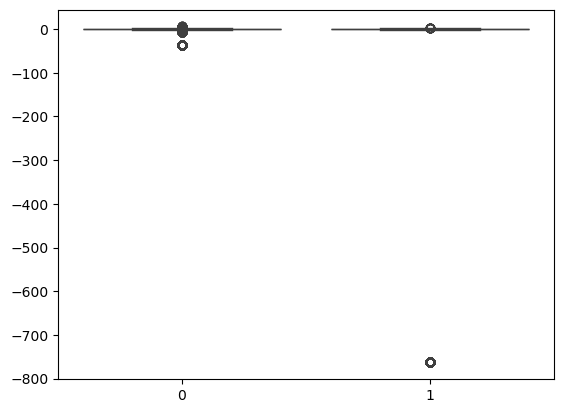

In [ ]:
import seaborn as sns
signal_tot = np.array(signal_tot)
sns.boxplot(data=signal_tot)
